# Verification Experiment Analysis

Summarize the computational phases recorded for the dedicated phase-analysis runs.

The first section summarizes dedicated MILP phase-analysis runs. The pruning section below compares all verifier families and does not rerun any benchmark.

In [1]:
from pathlib import Path
import json
import re

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 60)

In [2]:
def find_dataset_dir(dataset_name):
    candidates = [
        Path.cwd() / dataset_name,
        Path('/kaggle/input') / dataset_name,
        Path('/kaggle/working') / dataset_name,
        Path('/kaggle/input/datasets/mohhbrr') / dataset_name,
    ]
    for candidate in candidates:
        if candidate.exists() and (list(candidate.glob('*.csv')) or list(candidate.glob('*.json'))):
            return candidate
    kaggle_root = Path('/kaggle/input')
    if kaggle_root.exists():
        matches = list(kaggle_root.glob(f'**/{dataset_name}'))
        for match in matches:
            if list(match.glob('*.csv')) or list(match.glob('*.json')):
                return match
    raise FileNotFoundError(f'Could not find the {dataset_name} dataset.')

OPTIMIZATION_DATA_DIR = find_dataset_dir('fixing-binary-vars-experiment')
PHASE_DATA_DIR = find_dataset_dir('phase-analysis')
OPTIMIZATION_CSV_PATHS = sorted(OPTIMIZATION_DATA_DIR.glob('*.csv'))
OPTIMIZATION_JSON_PATHS = sorted(OPTIMIZATION_DATA_DIR.glob('*.json'))
PHASE_CSV_PATHS = sorted(PHASE_DATA_DIR.glob('*.csv'))
PHASE_JSON_PATHS = sorted(PHASE_DATA_DIR.glob('*.json'))
if not PHASE_JSON_PATHS:
    raise FileNotFoundError('No phase-analysis JSON artifacts found.')
print(f'Optimization data: {OPTIMIZATION_DATA_DIR}')
print(f'Phase-analysis data: {PHASE_DATA_DIR}')
[path.name for path in PHASE_JSON_PATHS]

Optimization data: /kaggle/input/datasets/mohhbrr/fixing-binary-vars-experiment/fixing-binary-vars-experiment
Phase-analysis data: /kaggle/input/datasets/mohhbrr/phase-analysis/phase-analysis


['no-fix-2-512-global-limit-10.json',
 'no-fix-3-100-global-limit-10-perturb-5.json',
 'no-fix-3-100-global-limit-10.json',
 'no-fix-4-1024-3pixel-limit-10.json']

In [3]:
def load_milp_csv(path):
    stem = path.stem
    configuration = (
        'MILP (stable-binary fixing)'
        if stem.startswith('fix-')
        else 'MILP (no stable-binary fixing)'
    )
    experiment = re.sub(r'^(fix|no-fix)-', '', stem)
    csv = pd.read_csv(path)
    csv['optimizer'] = 'MILP'
    csv['configuration'] = configuration
    csv['experiment'] = experiment
    csv['source_file'] = path.name
    return csv

def load_crown_csv(path):
    stem = path.stem
    match = re.match(r'crown-(.+)-([^-]+)$', stem)
    experiment = match.group(1) if match else stem.removeprefix('crown-')
    profile = match.group(2) if match else 'unknown'
    csv = pd.read_csv(path)
    csv['optimizer'] = 'ABCROWN'
    csv['configuration'] = f'ABCROWN ({profile})'
    csv['experiment'] = experiment
    csv['source_file'] = path.name
    csv['solver_status'] = csv.get('abcrown_status', csv.get('status'))
    return csv

tables = []
for path in OPTIMIZATION_CSV_PATHS:
    if path.name.startswith('crown-'):
        tables.append(load_crown_csv(path))
    elif path.name.startswith(('fix-', 'no-fix-')):
        tables.append(load_milp_csv(path))

results = pd.concat(tables, ignore_index=True)
results['solver_status'] = results.get('solver_status', results['status'])
known_experiment_order = [
    f'{network}-{region}'
    for region in ('3pixel', 'global')
    for network in ('3-100', '2-512', '4-1024')
]
experiment_order = known_experiment_order + [
    value for value in sorted(results['experiment'].unique())
    if value not in known_experiment_order
]
results['experiment'] = pd.Categorical(
    results['experiment'], categories=experiment_order, ordered=True
)
results[['optimizer', 'configuration', 'experiment', 'status']].head()

,optimizer,configuration,experiment,status
0,MILP,MILP (stable-binary fixing),2-512-3pixel,unsat
1,MILP,MILP (stable-binary fixing),2-512-3pixel,unsat
2,MILP,MILP (stable-binary fixing),2-512-3pixel,unknown
3,MILP,MILP (stable-binary fixing),2-512-3pixel,unsat
4,MILP,MILP (stable-binary fixing),2-512-3pixel,unsat


In [4]:
def load_milp_debug():
    rows = []
    for path in OPTIMIZATION_JSON_PATHS:
        if not path.name.startswith(('fix-', 'no-fix-')):
            continue
        configuration = (
            'MILP (stable-binary fixing)'
            if path.name.startswith('fix-')
            else 'MILP (no stable-binary fixing)'
        )
        experiment = re.sub(r'^(fix|no-fix)-|\.json$', '', path.name)
        for record in json.loads(path.read_text()):
            for direction, details in record.get('directions', {}).items():
                total = details.get('total', {})
                before = details.get('before_presolve', {})
                after = details.get('after_presolve', {})
                progress = details.get('cplex_progress', {})
                rows.append({
                    'optimizer': 'MILP',
                    'configuration': configuration,
                    'experiment': experiment,
                    'instance_id': record['instance_id'],
                    'direction': direction,
                    'binary_variables_before_presolve': total.get('unfixed_binary_variables', before.get('unfixed_binary_variables')),
                    'after_binary_variables': after.get('binary_variables', after.get('all_binary_variables')),
                    'presolve_time_sec': after.get('time_sec', after.get('presolve_time_sec')),
                    'nodes_processed': progress.get('nodes_processed'),
                    'nodes_remaining': progress.get('nodes_remaining'),
                    'lp_iterations': progress.get('iterations'),
                })
    return pd.DataFrame(rows)

milp_debug = load_milp_debug()
milp_debug['experiment'] = pd.Categorical(
    milp_debug['experiment'], categories=experiment_order, ordered=True
)
milp_debug.head()

,optimizer,configuration,experiment,instance_id,direction,binary_variables_before_presolve,after_binary_variables,presolve_time_sec,nodes_processed,nodes_remaining,lp_iterations
0,MILP,MILP (stable-binary fixing),2-512-3pixel,mnist_relu_2_512_three_pixel_0,nn1_minus_nn2,100,100,0.11,0,0,640
1,MILP,MILP (stable-binary fixing),2-512-3pixel,mnist_relu_2_512_three_pixel_0,nn2_minus_nn1,100,100,0.11,0,0,600
2,MILP,MILP (stable-binary fixing),2-512-3pixel,mnist_relu_2_512_three_pixel_1,nn1_minus_nn2,82,82,0.10,0,0,635
3,MILP,MILP (stable-binary fixing),2-512-3pixel,mnist_relu_2_512_three_pixel_1,nn2_minus_nn1,82,82,0.12,0,0,617
4,MILP,MILP (stable-binary fixing),2-512-3pixel,mnist_relu_2_512_three_pixel_2,nn1_minus_nn2,296,296,0.11,3074,1201,243651


## Runtime and verification outcome

`total_runtime_sec` is the sum of the per-instance `runtime_sec` values in each experiment.

In [5]:
summary = (results.groupby(['experiment', 'configuration'], observed=True)
           .agg(instances=('instance_id', 'nunique'),
                unsat=('status', lambda s: (s == 'unsat').sum()),
                unknown=('status', lambda s: (s == 'unknown').sum()),
                median_runtime_sec=('runtime_sec', 'median'),
                mean_runtime_sec=('runtime_sec', 'mean'),
                max_runtime_sec=('runtime_sec', 'max'),
                total_runtime_sec=('runtime_sec', lambda s: s.sum(min_count=1)))
           .reset_index())
summary.sort_values(['experiment', 'configuration'])

,experiment,configuration,instances,unsat,unknown,median_runtime_sec,mean_runtime_sec,max_runtime_sec,total_runtime_sec
0,3-100-3pixel,MILP (no stable-binary fixing),100,100,0,0.816889,0.856583,1.256593,85.658260
1,3-100-3pixel,MILP (stable-binary fixing),100,100,0,0.977064,1.185079,3.562281,118.507895
2,2-512-3pixel,MILP (no stable-binary fixing),100,99,1,9.224584,12.662520,127.668024,1266.252011
3,2-512-3pixel,MILP (stable-binary fixing),100,99,1,9.069469,11.144470,127.661698,1114.446981
4,4-1024-3pixel,MILP (no stable-binary fixing),100,99,1,99.091326,106.323188,494.391471,10632.318796
5,4-1024-3pixel,MILP (stable-binary fixing),100,100,0,98.629604,107.677553,484.445766,10767.755340
6,3-100-global,MILP (no stable-binary fixing),100,90,10,6.885712,21.878087,125.255432,2187.808715
7,3-100-global,MILP (stable-binary fixing),100,91,9,6.277228,22.060161,124.556902,2206.016058


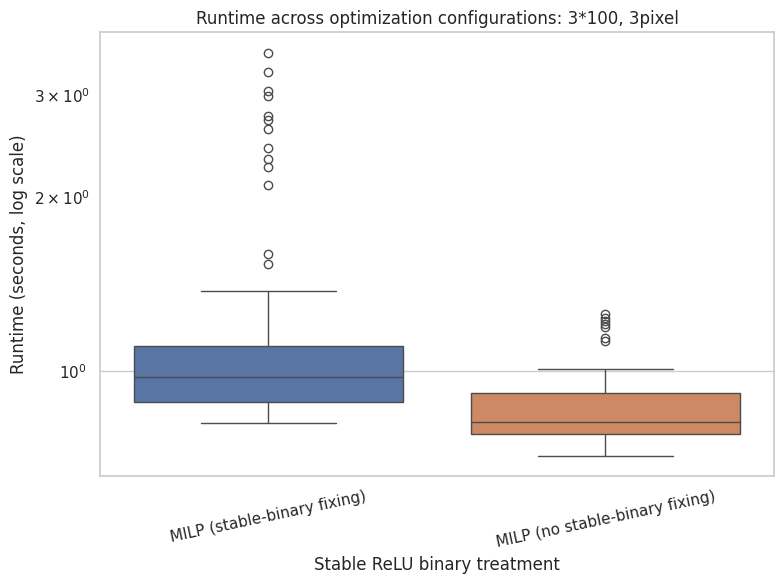

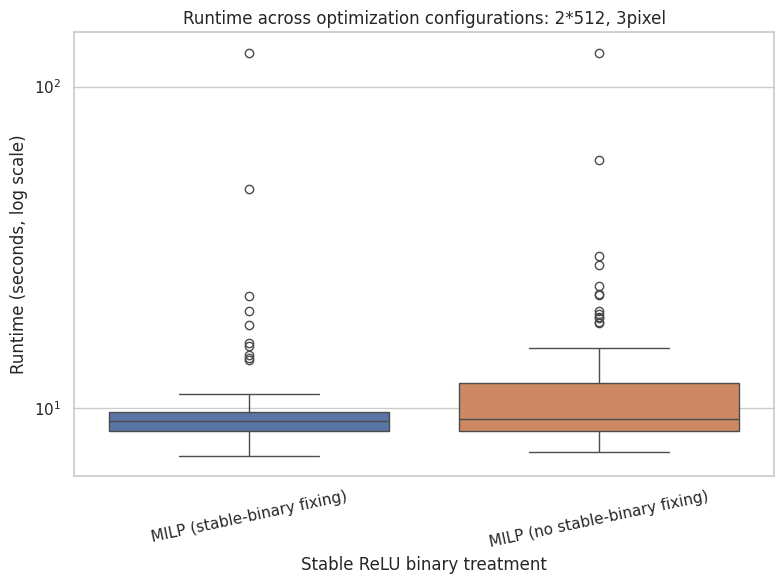

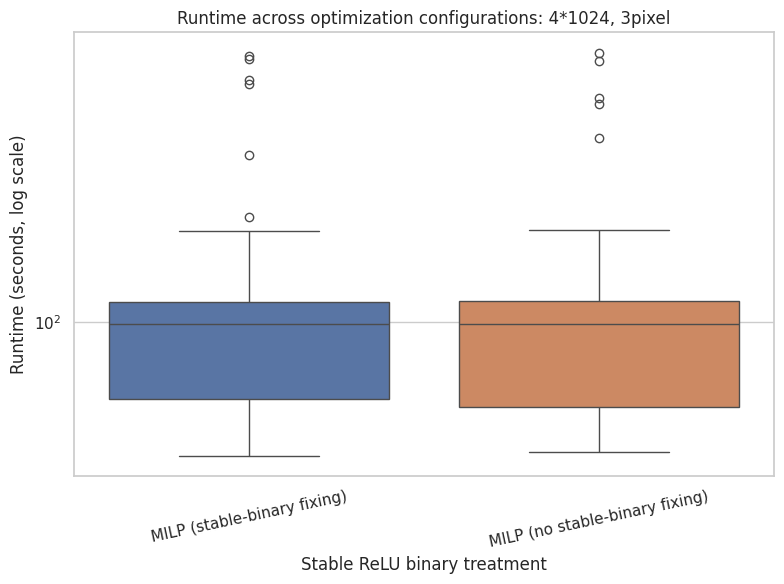

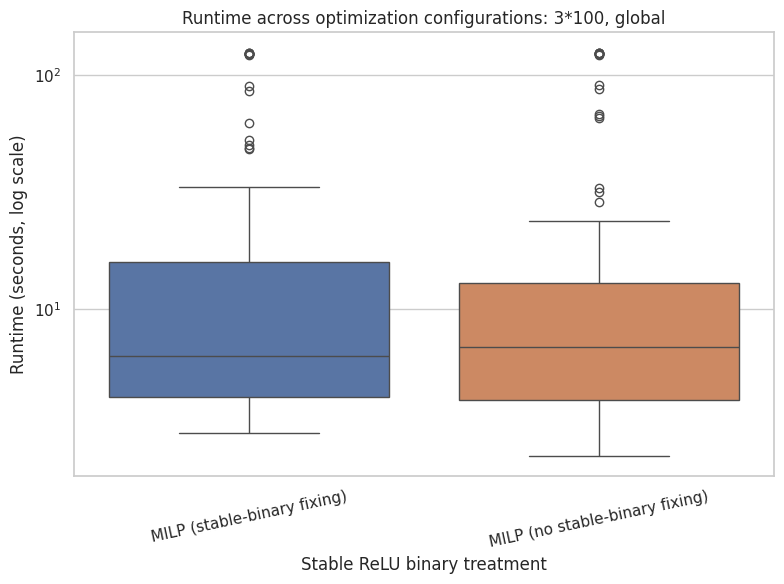

In [6]:
FIGURE_DIR = Path('/kaggle/working/figures')
if not FIGURE_DIR.parent.exists():
    FIGURE_DIR = Path('figures')
FIGURE_DIR.mkdir(exist_ok=True)

configuration_order = [
    'MILP (stable-binary fixing)',
    'MILP (no stable-binary fixing)',
]
for experiment in experiment_order:
    experiment_data = results[results['experiment'] == experiment]
    if experiment_data.empty:
        continue
    network, region = experiment.rsplit('-', maxsplit=1)
    network_label = network.replace('-', '*')
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.boxplot(
        data=experiment_data,
        x='configuration',
        y='runtime_sec',
        hue='configuration',
        order=configuration_order,
        hue_order=configuration_order,
        legend=False,
        ax=ax,
    )
    ax.set_yscale('log')
    ax.set_ylabel('Runtime (seconds, log scale)')
    ax.set_xlabel('Stable ReLU binary treatment')
    ax.tick_params(axis='x', labelrotation=12)
    ax.set_title(f'Runtime across optimization configurations: {network_label}, {region}')
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / f'runtime-{experiment}.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)

## MILP search behavior

In [7]:
initial_binary_lookup = {}
for path in OPTIMIZATION_JSON_PATHS:
    experiment = re.sub(r'^no-fix-|\.json$', '', path.name)
    for record in json.loads(path.read_text()):
        for direction, details in record.get('directions', {}).items():
            total = details.get('total', {})
            before = details.get('before_presolve', {})
            initial_binary_lookup[(experiment, record['instance_id'], direction)] = total.get(
                'all_binary_variables', before.get('all_binary_variables')
            )

milp_summary = milp_debug.copy()
milp_summary['initial_binaries'] = [
    initial_binary_lookup.get((str(experiment), instance_id, direction))
    for experiment, instance_id, direction in zip(
        milp_summary['experiment'],
        milp_summary['instance_id'],
        milp_summary['direction'],
    )
]
numeric_metrics = ['initial_binaries', 'binary_variables_before_presolve', 'after_binary_variables', 'nodes_processed', 'lp_iterations', 'nodes_remaining']
milp_summary[numeric_metrics] = milp_summary[numeric_metrics].apply(
    pd.to_numeric, errors='coerce'
)
milp_summary.groupby(['experiment', 'configuration'], observed=True).agg(
    median_initial_binaries=('initial_binaries', 'median'),
    median_binary_variables_before_presolve=('binary_variables_before_presolve', 'median'),
    median_binaries_after_presolve=('after_binary_variables', 'median'),
).reset_index().sort_values(['experiment', 'configuration'])

,experiment,configuration,median_initial_binaries,median_binary_variables_before_presolve,median_binaries_after_presolve
0,3-100-3pixel,MILP (no stable-binary fixing),420.0,420.0,71.0
1,3-100-3pixel,MILP (stable-binary fixing),420.0,71.0,71.0
2,2-512-3pixel,MILP (no stable-binary fixing),2048.0,2048.0,107.0
3,2-512-3pixel,MILP (stable-binary fixing),2048.0,99.0,107.0
4,4-1024-3pixel,MILP (no stable-binary fixing),6164.0,6164.0,376.0
5,4-1024-3pixel,MILP (stable-binary fixing),6164.0,355.0,376.0
6,3-100-global,MILP (no stable-binary fixing),420.0,420.0,99.0
7,3-100-global,MILP (stable-binary fixing),420.0,99.0,99.0


In [8]:
phase_names = ['bound_tightening', 'encode', 'solver_setup', 'solve']
phase_rows = []
for path in OPTIMIZATION_JSON_PATHS:
    if not path.name.startswith(('fix-', 'no-fix-')):
        continue
    configuration = (
        'MILP (stable-binary fixing)'
        if path.name.startswith('fix-')
        else 'MILP (no stable-binary fixing)'
    )
    experiment = re.sub(r'^(fix|no-fix)-|\.json$', '', path.name)
    for record in json.loads(path.read_text()):
        phases = record.get('phase_timings_sec', {}).get('phases', {})
        phase_seconds = {phase_name: 0.0 for phase_name in phase_names}
        for phase_name, phase_value in phases.items():
            if phase_name == 'bound_tightening' and isinstance(phase_value, dict):
                phase_seconds[phase_name] += sum(
                    value for value in phase_value.values()
                    if isinstance(value, (int, float))
                )
            elif isinstance(phase_value, dict):
                for nested_name, nested_value in phase_value.items():
                    if nested_name not in phase_names:
                        continue
                    if isinstance(nested_value, dict):
                        phase_seconds[nested_name] += sum(
                            value for value in nested_value.values()
                            if isinstance(value, (int, float))
                        )
                    elif isinstance(nested_value, (int, float)):
                        phase_seconds[nested_name] += nested_value
        phase_rows.append({
            'experiment': experiment,
            'configuration': configuration,
            **phase_seconds,
        })

phase_summary = pd.DataFrame(phase_rows)
phase_summary['experiment'] = pd.Categorical(
    phase_summary['experiment'], categories=experiment_order, ordered=True
)
phase_summary.groupby(['experiment', 'configuration'], observed=True)[phase_names].median().reset_index().sort_values(
    ['experiment', 'configuration']
)

,experiment,configuration,bound_tightening,encode,solver_setup,solve
0,3-100-3pixel,MILP (no stable-binary fixing),0.011881,1.184667,0.001482,0.804864
1,3-100-3pixel,MILP (stable-binary fixing),0.012977,1.422724,0.001768,0.963912
2,2-512-3pixel,MILP (no stable-binary fixing),2.792599,8.516216,0.001275,6.322987
3,2-512-3pixel,MILP (stable-binary fixing),2.806610,8.030069,0.001261,6.165315
4,4-1024-3pixel,MILP (no stable-binary fixing),31.724375,36.760206,0.002461,66.266680
5,4-1024-3pixel,MILP (stable-binary fixing),31.429065,36.247163,0.001901,66.328411
6,3-100-global,MILP (no stable-binary fixing),2.356346,1.629995,0.001475,2.725393
7,3-100-global,MILP (stable-binary fixing),2.523139,1.669356,0.001526,2.872950


## Phase-cost summary

The debug JSON records bound tightening, encoding, solver setup, and solver wall time for both directions. CPLEX presolve is inside `solve`; `solve_after_presolve` is therefore `solve - presolve`, not an additional cost.

In [9]:
phase_rows = []
direction_rows = []
for path in PHASE_JSON_PATHS:
    if not path.name.startswith(('fix-', 'no-fix-')):
        continue
    configuration = (
        'MILP (stable-binary fixing)' if path.name.startswith('fix-')
        else 'MILP (no stable-binary fixing)'
    )
    experiment = re.sub(r'^(fix|no-fix)-|\.json$', '', path.name)
    for record in json.loads(path.read_text()):
        phases = record.get('phase_timings_sec', {}).get('phases', {})
        bounds = phases.get('bound_tightening', {})
        bound = sum(v for v in bounds.values() if isinstance(v, (int, float)))
        instance = {
            'experiment': experiment, 'configuration': configuration,
            'instance_id': record.get('instance_id'), 'bound_tightening': bound,
        }
        for direction, details in record.get('directions', {}).items():
            timings = details.get('timings_sec', {})
            solve = timings.get('solve')
            presolve = details.get('after_presolve', {}).get('time_sec')
            direction_rows.append({
                'experiment': experiment, 'configuration': configuration,
                'instance_id': record.get('instance_id'), 'direction': direction,
                'encode': timings.get('encode'), 'solver_setup': timings.get('solver_setup'),
                'solve': solve, 'presolve': presolve,
                'solve_after_presolve': max(solve - presolve, 0)
                if solve is not None and presolve is not None else None,
                'binaries_before_presolve': details.get('before_presolve', {}).get('all_binary_variables'),
                'binaries_after_presolve': details.get('after_presolve', {}).get('binary_variables'),
                'nodes': details.get('cplex_progress', {}).get('nodes_processed'),
                'iterations': details.get('cplex_progress', {}).get('iterations'),
            })
            for phase in ('encode', 'solver_setup', 'solve'):
                instance[phase] = instance.get(phase, 0) + (timings.get(phase) or 0)
            instance['presolve'] = instance.get('presolve', 0) + (presolve or 0)
        instance['solve_after_presolve'] = max(instance.get('solve', 0) - instance.get('presolve', 0), 0)
        instance['total_solve'] = instance.get('solve', 0)
        instance['measured_total'] = sum(instance.get(p, 0) for p in (
            'bound_tightening', 'encode', 'solver_setup', 'solve'))
        phase_rows.append(instance)

phase_instances = pd.DataFrame(phase_rows)
direction_phases = pd.DataFrame(direction_rows)
phase_experiment_order = sorted(phase_instances['experiment'].unique())
for frame in (phase_instances, direction_phases):
    frame['experiment'] = pd.Categorical(
        frame['experiment'], categories=phase_experiment_order, ordered=True)

phase_columns = ['bound_tightening', 'encode', 'solver_setup', 'presolve',
                 'solve_after_presolve', 'total_solve', 'measured_total']
phase_medians = (phase_instances.groupby(['experiment', 'configuration'], observed=True)
                 [phase_columns].median().reset_index()
                 .sort_values(['experiment', 'configuration']))
phase_medians

,experiment,configuration,bound_tightening,encode,solver_setup,presolve,solve_after_presolve,total_solve,measured_total
0,2-512-global-limit-10,MILP (no stable-binary fixing),3.810419,6.247475,0.001431,0.460,244.483674,244.923674,254.351010
1,3-100-global-limit-10,MILP (no stable-binary fixing),1.687039,1.143769,0.001317,0.060,1.782945,1.842945,4.491077
2,3-100-global-limit-10-perturb-5,MILP (no stable-binary fixing),1.776038,1.127105,0.001341,0.060,240.728808,240.793808,243.708299
3,4-1024-3pixel-limit-10,MILP (no stable-binary fixing),24.078316,21.974279,0.001804,1.685,54.964773,56.649773,103.041733


In [10]:
solver_numeric = ['presolve', 'solve_after_presolve', 'binaries_before_presolve',
                  'binaries_after_presolve', 'nodes', 'iterations']
direction_phases[solver_numeric] = direction_phases[solver_numeric].apply(
    pd.to_numeric, errors='coerce')

solver_medians = (direction_phases.groupby(
    ['experiment', 'configuration', 'direction'], observed=True)
    [['presolve', 'solve_after_presolve', 'binaries_before_presolve',
      'binaries_after_presolve', 'nodes', 'iterations']]
    .median().reset_index()
    .sort_values(['experiment', 'configuration', 'direction']))
solver_medians

,experiment,configuration,direction,presolve,solve_after_presolve,binaries_before_presolve,binaries_after_presolve,nodes,iterations
0,2-512-global-limit-10,MILP (no stable-binary fixing),nn1_minus_nn2,0.23,122.231107,2048.0,486.0,840.0,108307.0
1,2-512-global-limit-10,MILP (no stable-binary fixing),nn2_minus_nn1,0.23,122.259154,2048.0,486.0,634.0,94663.0
2,3-100-global-limit-10,MILP (no stable-binary fixing),nn1_minus_nn2,0.03,0.943257,420.0,100.0,0.0,472.0
3,3-100-global-limit-10,MILP (no stable-binary fixing),nn2_minus_nn1,0.03,0.844614,420.0,100.0,0.0,508.5
4,3-100-global-limit-10-perturb-5,MILP (no stable-binary fixing),nn1_minus_nn2,0.03,120.375032,420.0,178.0,31565.0,3264505.5
5,3-100-global-limit-10-perturb-5,MILP (no stable-binary fixing),nn2_minus_nn1,0.03,120.344575,420.0,178.0,31809.0,3234240.5
6,4-1024-3pixel-limit-10,MILP (no stable-binary fixing),nn1_minus_nn2,0.84,28.241363,6164.0,404.0,0.0,1796.5
7,4-1024-3pixel-limit-10,MILP (no stable-binary fixing),nn2_minus_nn1,0.85,26.482144,6164.0,404.0,0.0,1846.5


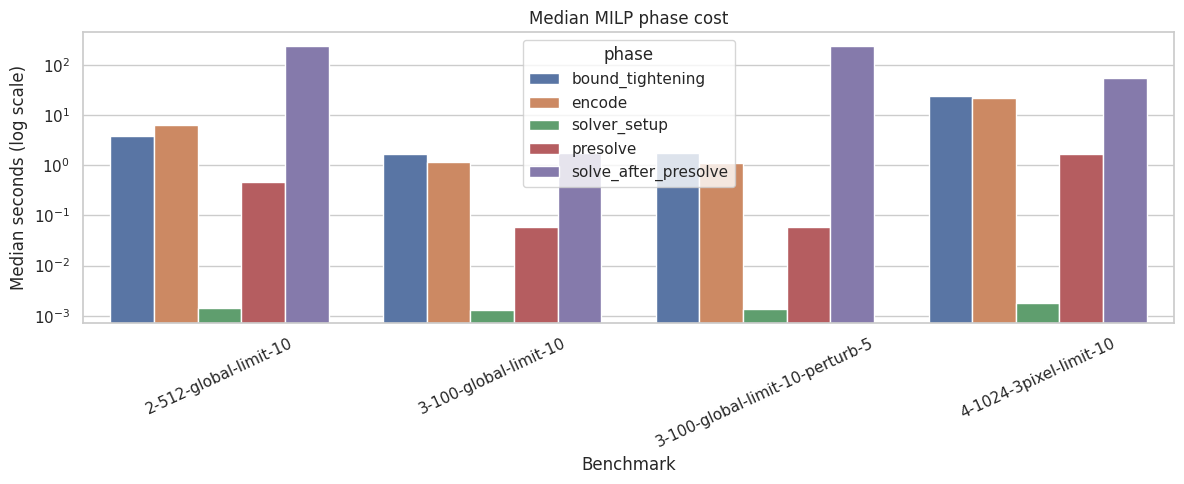

In [11]:
plot_data = phase_medians.melt(
    id_vars=['experiment', 'configuration'],
    value_vars=['bound_tightening', 'encode', 'solver_setup',
                'presolve', 'solve_after_presolve'],
    var_name='phase', value_name='median_seconds')
plot_data = plot_data[plot_data['median_seconds'] > 0]
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=plot_data, x='experiment', y='median_seconds',
            hue='phase', errorbar=None, ax=ax)
ax.set_yscale('log')
ax.set_ylabel('Median seconds (log scale)')
ax.set_xlabel('Benchmark')
ax.set_title('Median MILP phase cost')
ax.tick_params(axis='x', rotation=25)
plt.tight_layout()

## Interpretation

Use the first table for overall phase cost, and the second for directional solver behavior. Presolve is reported separately for diagnosis but is already included in `solve`; the post-presolve value is only a derived remainder.

# Pruning method comparison

This section treats pruning as a controlled method-comparison experiment. It loads every CSV in `prune-experiment/results`, normalizes solver-specific statuses, measures crossover behavior, and extracts disagreement cases for diagnosis.

Expected filename: `<method>__<architecture>__<mode>__p<rate>.csv`. Supported method keys are `milp`, `milp_abcrown`, `abcrown`, `reludiff`, and `neurodiff`. Missing configurations are reported rather than silently dropped.

Each CSV row is one benchmark-instance result. Consequently, an experiment's total runtime is the sum of `runtime_sec` over its rows. Extra solver-specific columns are retained but are not included in this sum.

In [12]:
def find_pruning_data_dir():
    candidates = [
        Path.cwd() / 'prune-experiment',
        Path('/kaggle/input/prune-experiment/prune-experiment'),
        Path('/kaggle/input/prune-experiment'),
    ]
    for candidate in candidates:
        if (candidate / 'results').is_dir():
            return candidate
    kaggle_input = Path('/kaggle/input')
    if kaggle_input.is_dir():
        for results_dir in kaggle_input.glob('**/results'):
            if any(results_dir.glob('*.csv')):
                return results_dir.parent
    raise FileNotFoundError(
        'Could not find a pruning data directory containing results/*.csv')

PRUNING_DATA_DIR = find_pruning_data_dir()
PRUNING_RESULTS_DIR = PRUNING_DATA_DIR / 'results'
PRUNING_DEBUG_DIR = PRUNING_DATA_DIR / 'debug'
print(f'Pruning data: {PRUNING_DATA_DIR}')
METHOD_LABELS = {
    'milp': 'Relational-MILP',
    'milp_abcrown': 'Relational-MILP + ab-CROWN bounds',
    'abcrown': 'complete ab-CROWN',
    'reludiff': 'ReluDiff',
    'neurodiff': 'NeuroDiff',
}
METHOD_ORDER = list(METHOD_LABELS.values())
RESULT_NAME = re.compile(
    r'^(?P<method>milp_abcrown|milp|abcrown|reludiff|neurodiff)'
    r'__(?P<architecture>.+)__(?P<mode>global|three_pixel)__p(?P<pruning_rate>\d+)$'
)

def normalized_outcome(status):
    status = str(status).strip().lower()
    if status in {'unsat', 'verified', 'verified-by-bounds', 'safe'}:
        return 'verified'
    if status in {'sat', 'falsified', 'unsafe-pgd', 'unsafe-bab', 'adv found'}:
        return 'falsified'
    if status == 'timeout':
        return 'timeout'
    return 'unknown'

def load_pruning_results(results_dir=PRUNING_RESULTS_DIR):
    frames = []
    for path in sorted(results_dir.glob('*.csv')):
        match = RESULT_NAME.match(path.stem)
        if not match:
            print(f'Skipping unrecognized result filename: {path.name}')
            continue
        frame = pd.read_csv(path)
        required = {'instance_id', 'status', 'runtime_sec'}
        missing = required - set(frame.columns)
        if missing:
            raise ValueError(f'{path}: missing columns {sorted(missing)}')
        for key, value in match.groupdict().items():
            frame[key] = int(value) if key == 'pruning_rate' else value
        frame['method'] = frame['method'].map(METHOD_LABELS)
        frame['outcome'] = frame['status'].map(normalized_outcome)
        frame['runtime_sec'] = pd.to_numeric(frame['runtime_sec'], errors='coerce')
        frame['solved'] = frame['outcome'].isin(['verified', 'falsified'])
        frame['source_file'] = path.name
        frames.append(frame)
    if not frames:
        raise FileNotFoundError(f'No recognized pruning CSVs in {results_dir.resolve()}')
    result = pd.concat(frames, ignore_index=True)
    result['method'] = pd.Categorical(result['method'], METHOD_ORDER, ordered=True)
    return result

pruning = load_pruning_results()
config_columns = ['method', 'architecture', 'mode', 'pruning_rate']
coverage = (pruning.groupby(config_columns, observed=True)
            .agg(instances=('instance_id', 'nunique'))
            .reset_index().sort_values(config_columns))
expected_coverage = pd.MultiIndex.from_product(
    [METHOD_ORDER, sorted(pruning['architecture'].unique()),
     sorted(pruning['mode'].unique()), sorted(pruning['pruning_rate'].unique())],
    names=config_columns).to_frame(index=False)
coverage = expected_coverage.merge(coverage, on=config_columns, how='left')
coverage['instances'] = coverage['instances'].fillna(0).astype(int)
missing_configurations = coverage[coverage['instances'] == 0].copy()
print(f'{len(pruning):,} rows from {pruning.source_file.nunique()} result files; '
      f'{len(missing_configurations)} configurations missing from the observed grid')
display(coverage)
missing_configurations

Pruning data: /kaggle/input/datasets/mohhbrr/prune-experiment/prune-experiment
7,100 rows from 71 result files; 109 configurations missing from the observed grid


,method,architecture,mode,pruning_rate,instances
0,Relational-MILP,mnist_relu_2_512,global,5,0
1,Relational-MILP,mnist_relu_2_512,global,10,0
2,Relational-MILP,mnist_relu_2_512,global,20,0
3,Relational-MILP,mnist_relu_2_512,global,30,0
4,Relational-MILP,mnist_relu_2_512,global,40,0
...,...,...,...,...,...
175,NeuroDiff,mnist_relu_4_1024,three_pixel,10,100
176,NeuroDiff,mnist_relu_4_1024,three_pixel,20,100
177,NeuroDiff,mnist_relu_4_1024,three_pixel,30,0
178,NeuroDiff,mnist_relu_4_1024,three_pixel,40,100


,method,architecture,mode,pruning_rate,instances
0,Relational-MILP,mnist_relu_2_512,global,5,0
1,Relational-MILP,mnist_relu_2_512,global,10,0
2,Relational-MILP,mnist_relu_2_512,global,20,0
3,Relational-MILP,mnist_relu_2_512,global,30,0
4,Relational-MILP,mnist_relu_2_512,global,40,0
...,...,...,...,...,...
170,NeuroDiff,mnist_relu_4_1024,global,20,0
171,NeuroDiff,mnist_relu_4_1024,global,30,0
172,NeuroDiff,mnist_relu_4_1024,global,40,0
173,NeuroDiff,mnist_relu_4_1024,global,50,0


In [15]:
outcome_counts = (pruning.pivot_table(
    index=config_columns, columns='outcome', values='instance_id',
    aggfunc='count', fill_value=0, observed=True)
    .reindex(columns=['verified', 'falsified', 'timeout', 'unknown'], fill_value=0)
    .reset_index())

# Each result CSV contains one row per benchmark instance. Sum runtime_sec over
# those rows; do not sum phase/debug columns, which may overlap with runtime_sec.
runtime_summary = (pruning.groupby(config_columns, observed=True)
    .agg(result_rows=('instance_id', 'size'),
         instances=('instance_id', 'nunique'),
         runtime_values=('runtime_sec', 'count'),
         solved=('solved', 'sum'),
         median_runtime_sec=('runtime_sec', 'median'),
         p90_runtime_sec=('runtime_sec', lambda x: x.quantile(.90)),
         total_runtime_sec=('runtime_sec', lambda x: x.sum(min_count=1)))
    .reset_index())
pruning_summary = outcome_counts.merge(runtime_summary, on=config_columns)
pruning_summary['success_rate'] = pruning_summary['solved'] / pruning_summary['instances']
display(pruning_summary.sort_values(config_columns))

# Explicitly retain source_file in this view so that the total for every input
# CSV (that is, every evaluated experiment) can be checked independently.
experiment_runtime = (pruning.groupby(config_columns + ['source_file'], observed=True)
    .agg(result_rows=('instance_id', 'size'),
         instances=('instance_id', 'nunique'),
         runtime_values=('runtime_sec', 'count'),
         total_runtime_sec=('runtime_sec', lambda x: x.sum(min_count=1)))
    .reset_index()
    .sort_values(config_columns + ['source_file']))
display(experiment_runtime)
experiment_runtime.to_csv("experiment_runtime.csv", index=False)

,method,architecture,mode,pruning_rate,verified,falsified,timeout,unknown,result_rows,instances,runtime_values,solved,median_runtime_sec,p90_runtime_sec,total_runtime_sec,success_rate
0,Relational-MILP + ab-CROWN bounds,mnist_relu_2_512,global,40,0,85,0,15,100,100,100,85,89.072198,127.095609,9072.496769,0.85
1,Relational-MILP + ab-CROWN bounds,mnist_relu_2_512,global,50,0,94,0,6,100,100,100,94,81.405605,114.580505,7592.553700,0.94
2,Relational-MILP + ab-CROWN bounds,mnist_relu_2_512,three_pixel,5,100,0,0,0,100,100,100,100,7.963175,8.961844,886.724924,1.00
3,Relational-MILP + ab-CROWN bounds,mnist_relu_2_512,three_pixel,10,100,0,0,0,100,100,100,100,7.969916,10.007559,944.364641,1.00
4,Relational-MILP + ab-CROWN bounds,mnist_relu_2_512,three_pixel,20,84,14,0,2,100,100,100,98,8.241043,27.738738,1342.393010,0.98
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66,NeuroDiff,mnist_relu_4_1024,three_pixel,5,100,0,0,0,100,100,100,100,5.952217,6.337748,600.399186,1.00
67,NeuroDiff,mnist_relu_4_1024,three_pixel,10,100,0,0,0,100,100,100,100,8.679256,22.726851,1166.204022,1.00
68,NeuroDiff,mnist_relu_4_1024,three_pixel,20,0,0,100,0,100,100,100,0,60.036951,60.082380,6004.995451,0.00
69,NeuroDiff,mnist_relu_4_1024,three_pixel,40,0,87,13,0,100,100,100,87,52.060778,60.029304,5110.302462,0.87


,method,architecture,mode,pruning_rate,source_file,result_rows,instances,runtime_values,total_runtime_sec
0,Relational-MILP + ab-CROWN bounds,mnist_relu_2_512,global,40,milp_abcrown__mnist_relu_2_512__global__p40.csv,100,100,100,9072.496769
1,Relational-MILP + ab-CROWN bounds,mnist_relu_2_512,global,50,milp_abcrown__mnist_relu_2_512__global__p50.csv,100,100,100,7592.553700
2,Relational-MILP + ab-CROWN bounds,mnist_relu_2_512,three_pixel,5,milp_abcrown__mnist_relu_2_512__three_pixel__p...,100,100,100,886.724924
3,Relational-MILP + ab-CROWN bounds,mnist_relu_2_512,three_pixel,10,milp_abcrown__mnist_relu_2_512__three_pixel__p...,100,100,100,944.364641
4,Relational-MILP + ab-CROWN bounds,mnist_relu_2_512,three_pixel,20,milp_abcrown__mnist_relu_2_512__three_pixel__p...,100,100,100,1342.393010
...,...,...,...,...,...,...,...,...,...
66,NeuroDiff,mnist_relu_4_1024,three_pixel,5,neurodiff__mnist_relu_4_1024__three_pixel__p5.csv,100,100,100,600.399186
67,NeuroDiff,mnist_relu_4_1024,three_pixel,10,neurodiff__mnist_relu_4_1024__three_pixel__p10...,100,100,100,1166.204022
68,NeuroDiff,mnist_relu_4_1024,three_pixel,20,neurodiff__mnist_relu_4_1024__three_pixel__p20...,100,100,100,6004.995451
69,NeuroDiff,mnist_relu_4_1024,three_pixel,40,neurodiff__mnist_relu_4_1024__three_pixel__p40...,100,100,100,5110.302462


saved /kaggle/working/figures/head-to-head-global-mnist_relu_3_100.png


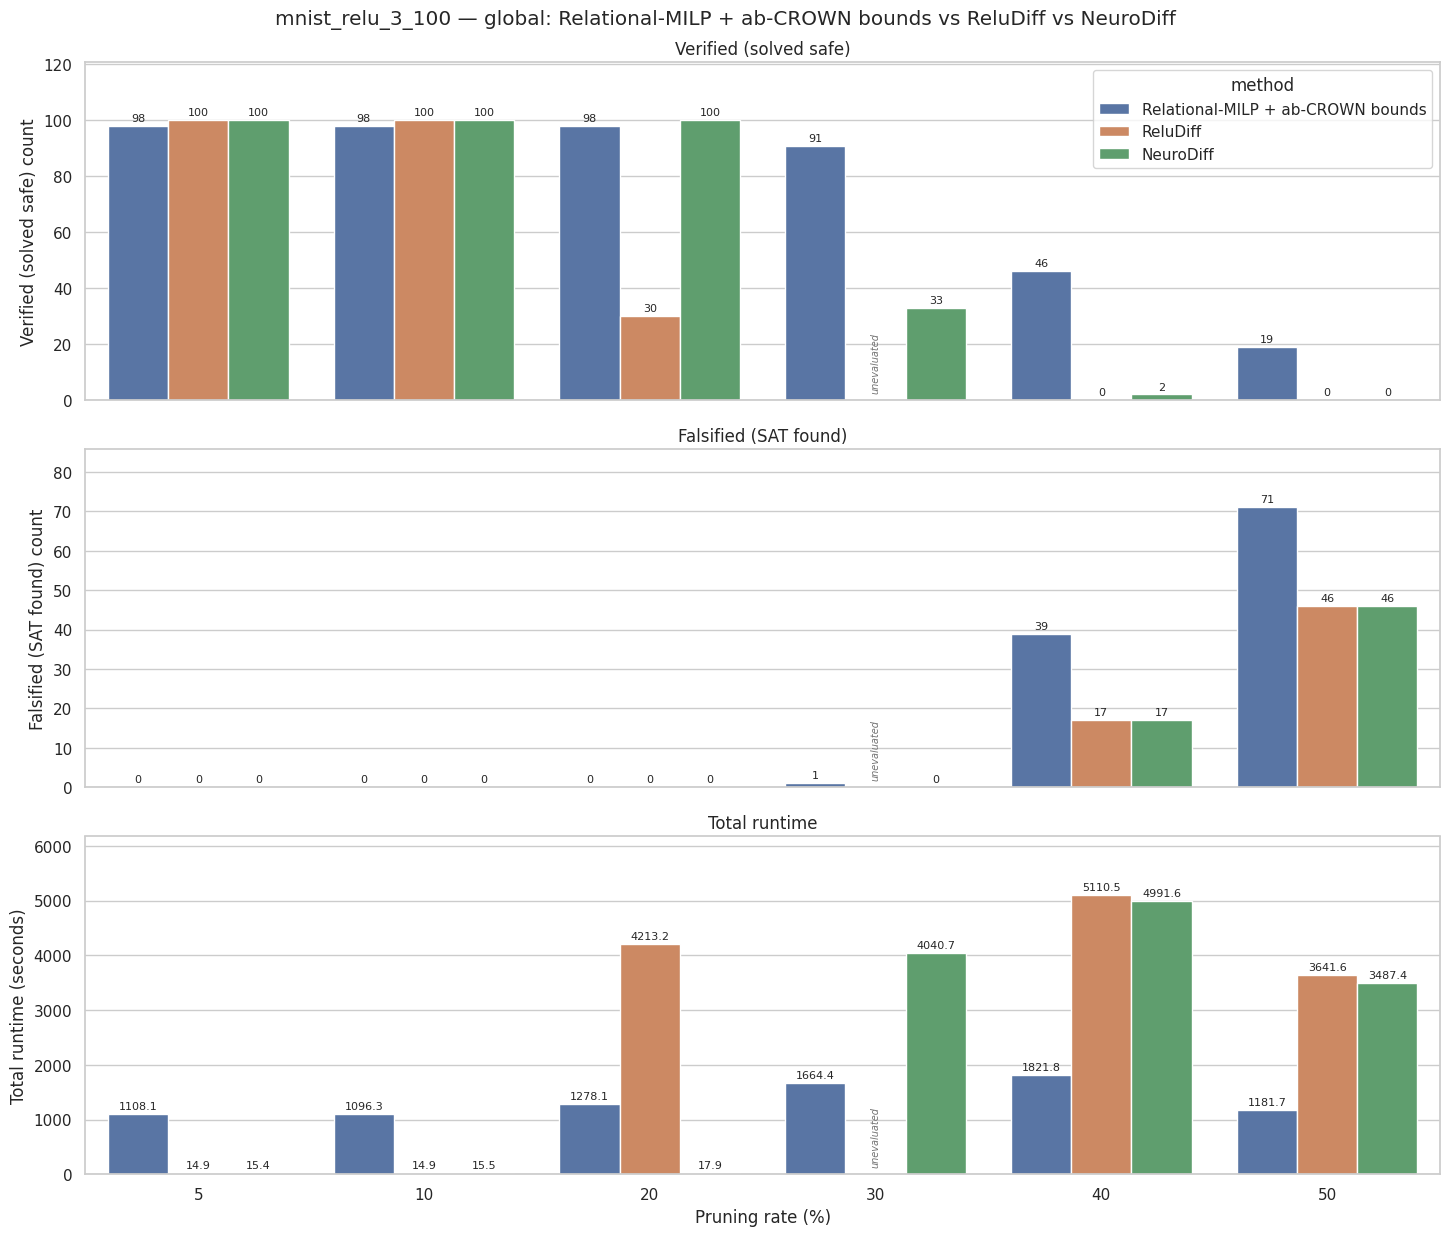

saved /kaggle/working/figures/head-to-head-global-mnist_relu_2_512.png


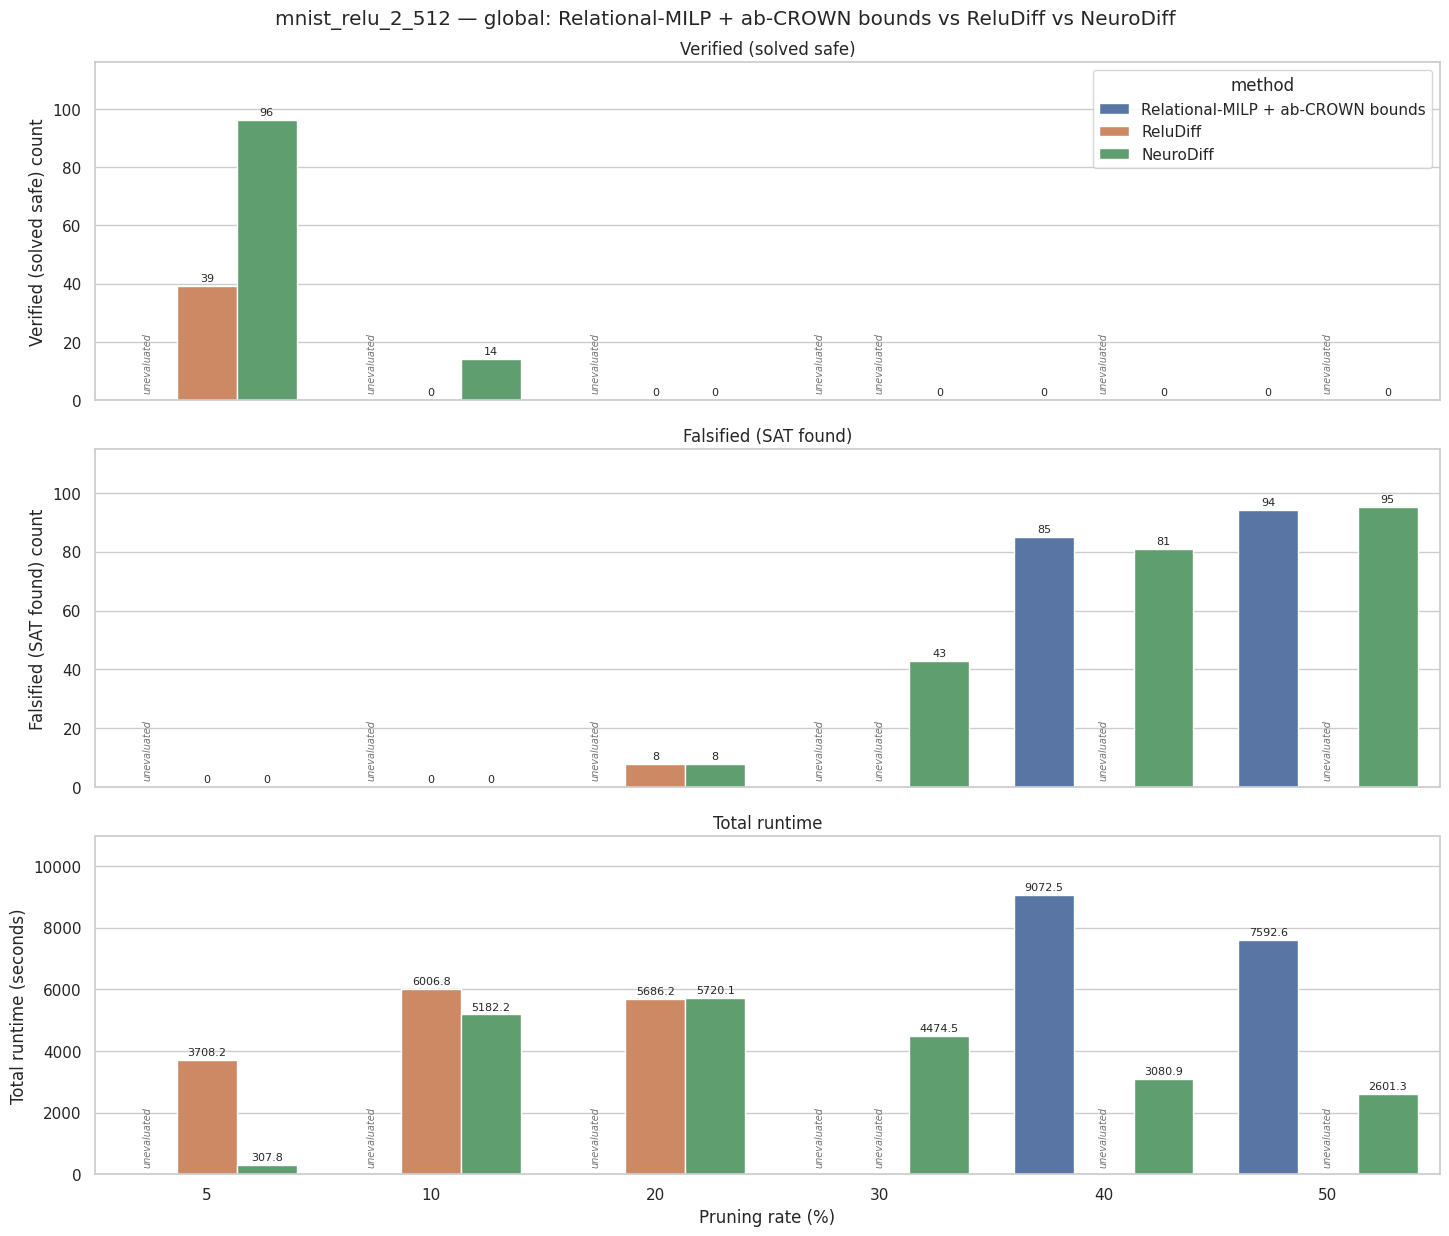

No ['Relational-MILP + ab-CROWN bounds', 'ReluDiff', 'NeuroDiff'] results for mnist_relu_4_1024 / global — skipping figure.
saved /kaggle/working/figures/head-to-head-three_pixel-mnist_relu_3_100.png


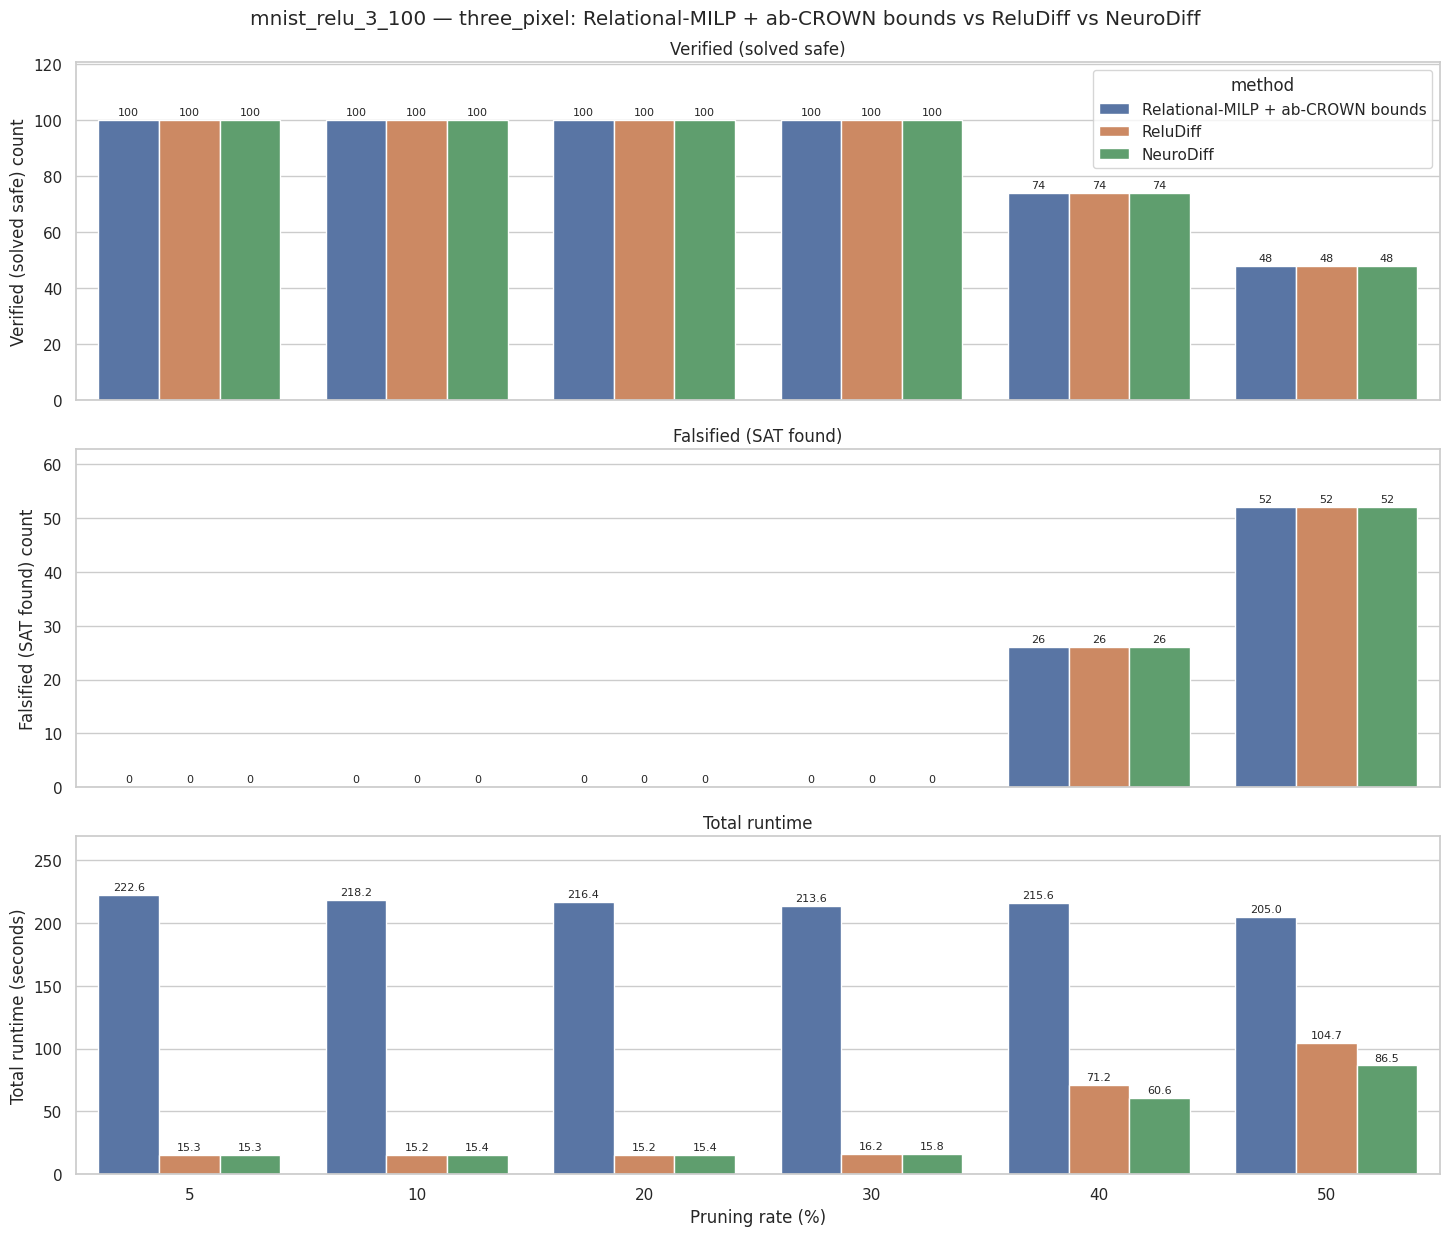

saved /kaggle/working/figures/head-to-head-three_pixel-mnist_relu_2_512.png


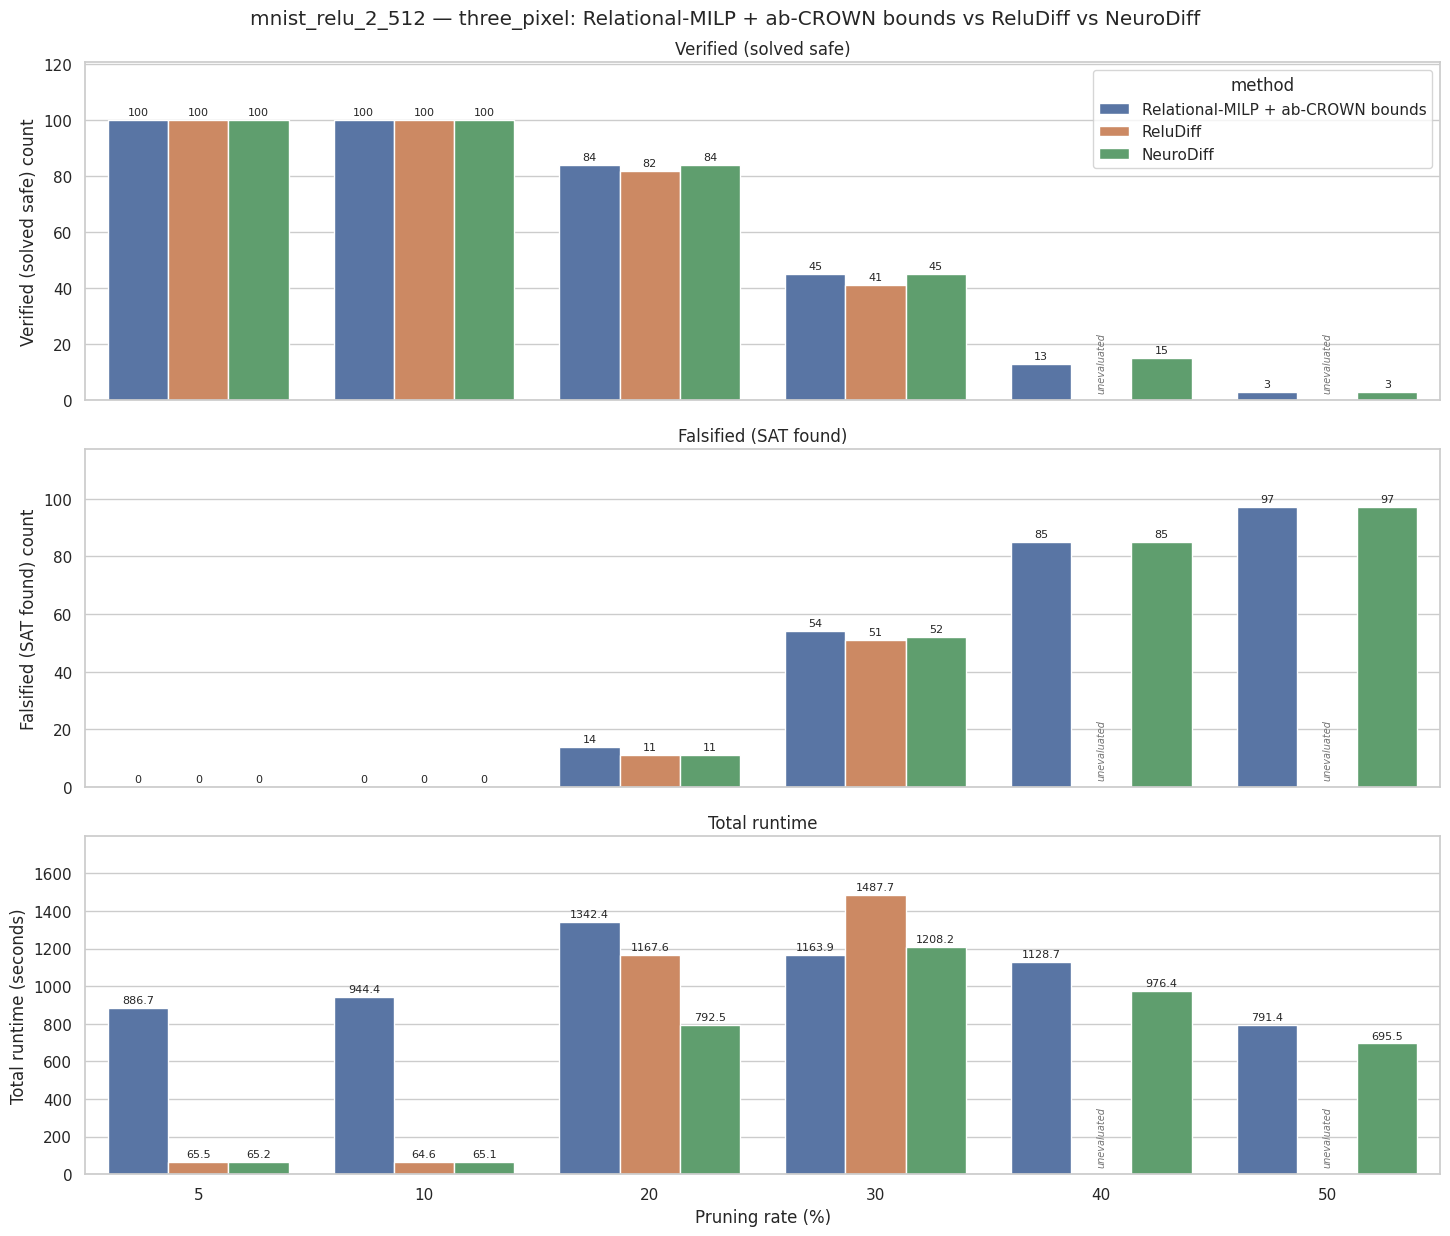

saved /kaggle/working/figures/head-to-head-three_pixel-mnist_relu_4_1024.png


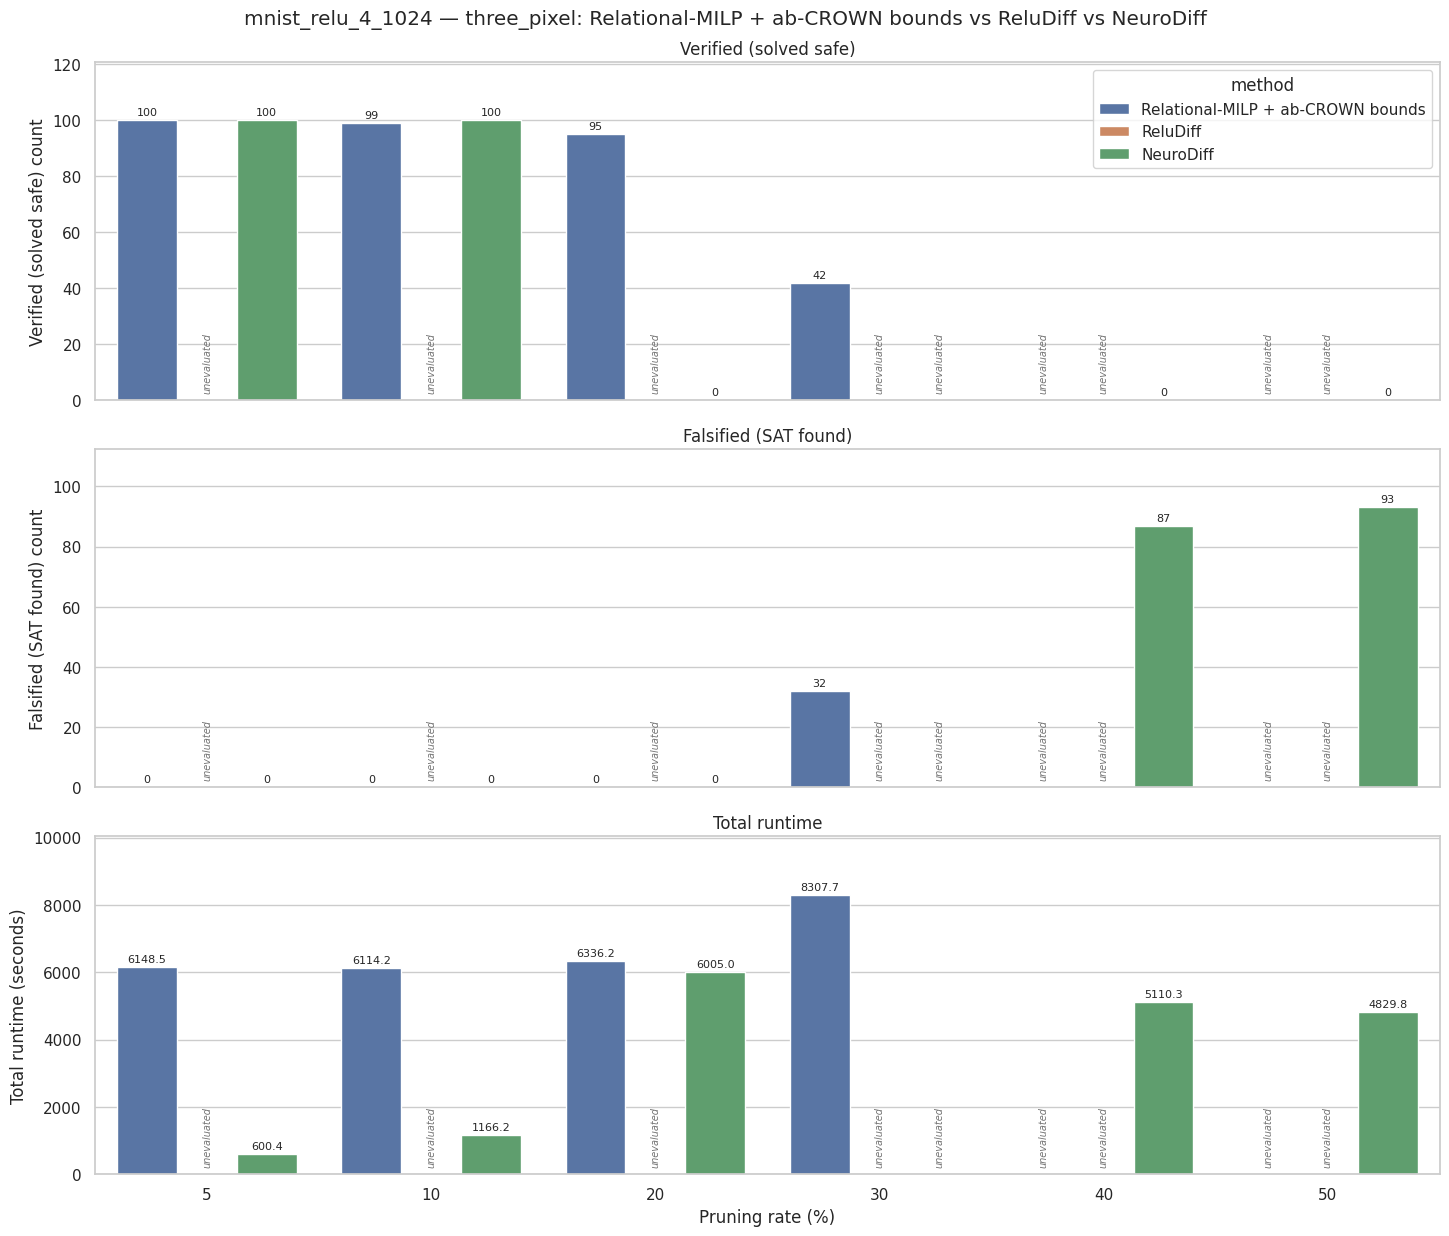

,method,pruning_rate,falsified,timeout,unknown,verified,runtime_values,total_runtime_sec,architecture,mode
0,Relational-MILP + ab-CROWN bounds,5,0.0,0.0,2.0,98.0,100.0,1108.054684,mnist_relu_3_100,global
1,Relational-MILP + ab-CROWN bounds,10,0.0,0.0,2.0,98.0,100.0,1096.340855,mnist_relu_3_100,global
2,Relational-MILP + ab-CROWN bounds,20,0.0,0.0,2.0,98.0,100.0,1278.066797,mnist_relu_3_100,global
3,Relational-MILP + ab-CROWN bounds,30,1.0,0.0,8.0,91.0,100.0,1664.437114,mnist_relu_3_100,global
4,Relational-MILP + ab-CROWN bounds,40,39.0,0.0,15.0,46.0,100.0,1821.793049,mnist_relu_3_100,global
...,...,...,...,...,...,...,...,...,...,...
85,NeuroDiff,10,0.0,0.0,0.0,100.0,100.0,1166.204022,mnist_relu_4_1024,three_pixel
86,NeuroDiff,20,0.0,100.0,0.0,0.0,100.0,6004.995451,mnist_relu_4_1024,three_pixel
87,NeuroDiff,30,NaN,NaN,NaN,NaN,NaN,NaN,mnist_relu_4_1024,three_pixel
88,NeuroDiff,40,87.0,13.0,0.0,0.0,100.0,5110.302462,mnist_relu_4_1024,three_pixel


In [14]:
# Head-to-head: Relational-MILP + ab-CROWN  vs  ReluDiff  vs  NeuroDiff.
# One figure per (mode, architecture): all `global` figures first, then all
# `three_pixel` ones. Architectures follow 3*100 -> 2*512 -> 4*1024.
# Every figure spans the full pruning-rate grid; a (method, rate) cell that was
# never evaluated gets an "unevaluated" placeholder instead of a bar, so all
# figures keep the same width. The last panel sums runtime_sec across all rows
# in the corresponding result CSV.
COMPARE_METHODS = ['Relational-MILP + ab-CROWN bounds', 'ReluDiff', 'NeuroDiff']
COMPARE_PALETTE = {'Relational-MILP + ab-CROWN bounds': '#4c72b0',
                   'ReluDiff': '#dd8452',
                   'NeuroDiff': '#55a868'}
MODE_ORDER = ['global', 'three_pixel']
ARCHITECTURE_ORDER = ['mnist_relu_3_100', 'mnist_relu_2_512', 'mnist_relu_4_1024']

observed_architectures = set(pruning['architecture'].unique())
architecture_order = [a for a in ARCHITECTURE_ORDER if a in observed_architectures]
architecture_order += sorted(observed_architectures - set(architecture_order))
mode_order = [m for m in MODE_ORDER if m in set(pruning['mode'])]
PRUNING_RATES = sorted(pruning['pruning_rate'].unique())


def annotate_head_to_head(ax, evaluated, fmt='%d', available=None):
    """Label evaluated bars and distinguish missing runtimes from missing runs."""
    available = evaluated if available is None else available
    ax.set_ylim(0, max(ax.get_ylim()[1], 1) * 1.15)
    top = ax.get_ylim()[1]
    for method, container in zip(COMPARE_METHODS, ax.containers):
        labels = []
        for rate, bar, value in zip(PRUNING_RATES, container, container.datavalues):
            key = (method, rate)
            if key not in evaluated:
                labels.append('')
                bar.set_visible(False)
                ax.text(bar.get_x() + bar.get_width() / 2, 0.02 * top, 'unevaluated',
                        rotation=90, ha='center', va='bottom', fontsize=7,
                        color='0.45', style='italic')
            elif key not in available:
                labels.append('')
                bar.set_visible(False)
                ax.text(bar.get_x() + bar.get_width() / 2, 0.02 * top, 'n/a',
                        rotation=90, ha='center', va='bottom', fontsize=7,
                        color='0.45', style='italic')
            else:
                labels.append(fmt % value)
        ax.bar_label(container, labels=labels, padding=2, fontsize=8)


def plot_head_to_head(data, architecture, mode, outcomes=('verified', 'falsified')):
    """Counts plus total runtime for one architecture / input-mode experiment."""
    selected = data[(data['architecture'] == architecture) &
                    (data['mode'] == mode) &
                    (data['method'].isin(COMPARE_METHODS))]
    per_rate = (selected.groupby(['method', 'pruning_rate', 'outcome'], observed=True)
                .agg(count=('instance_id', 'count'))
                .reset_index())
    runtime_per_rate = (selected.groupby(['method', 'pruning_rate'], observed=True)
                        .agg(runtime_values=('runtime_sec', 'count'),
                             total_runtime_sec=(
                                 'runtime_sec', lambda x: x.sum(min_count=1)))
                        .reset_index())

    # A (method, rate) pair is "evaluated" when any result row exists for it,
    # even if the count for a given outcome happens to be zero.
    evaluated = set(map(tuple, selected[['method', 'pruning_rate']]
                        .drop_duplicates().to_numpy()))
    runtime_available = set(map(tuple, runtime_per_rate.loc[
        runtime_per_rate['runtime_values'] > 0, ['method', 'pruning_rate']
    ].to_numpy()))
    grid = pd.MultiIndex.from_product([COMPARE_METHODS, PRUNING_RATES],
                                      names=['method', 'pruning_rate']).to_frame(index=False)
    rate_labels = [str(rate) for rate in PRUNING_RATES]

    panel_count = len(outcomes) + 1
    fig, axes = plt.subplots(panel_count, 1, squeeze=False, sharex=True,
                             figsize=(0.62 * len(PRUNING_RATES) * len(COMPARE_METHODS) + 3.5,
                                      4.2 * panel_count))
    for row, outcome in enumerate(outcomes):
        ax = axes[row][0]
        panel = grid.merge(per_rate[per_rate['outcome'] == outcome],
                           on=['method', 'pruning_rate'], how='left')
        panel['count'] = panel['count'].fillna(0)
        panel['rate_label'] = panel['pruning_rate'].astype(str)
        sns.barplot(data=panel, x='rate_label', y='count', hue='method',
                    order=rate_labels, hue_order=COMPARE_METHODS,
                    palette=COMPARE_PALETTE, ax=ax)
        annotate_head_to_head(ax, evaluated)
        label = 'Verified (solved safe)' if outcome == 'verified' \
            else 'Falsified (SAT found)' if outcome == 'falsified' \
            else outcome.capitalize()
        ax.set(xlabel='Pruning rate (%)', ylabel=f'{label} count', title=label)
        if row:
            legend = ax.get_legend()
            if legend:
                legend.remove()

    runtime_ax = axes[-1][0]
    runtime_panel = grid.merge(runtime_per_rate, on=['method', 'pruning_rate'], how='left')
    runtime_panel['total_runtime_sec'] = runtime_panel['total_runtime_sec'].fillna(0)
    runtime_panel['rate_label'] = runtime_panel['pruning_rate'].astype(str)
    sns.barplot(data=runtime_panel, x='rate_label', y='total_runtime_sec', hue='method',
                order=rate_labels, hue_order=COMPARE_METHODS,
                palette=COMPARE_PALETTE, ax=runtime_ax)
    annotate_head_to_head(runtime_ax, evaluated, fmt='%.1f',
                          available=runtime_available)
    runtime_ax.set(xlabel='Pruning rate (%)', ylabel='Total runtime (seconds)',
                   title='Total runtime')
    runtime_legend = runtime_ax.get_legend()
    if runtime_legend:
        runtime_legend.remove()

    # Return a compact experiment table containing both outcomes and runtime.
    outcome_wide = (per_rate.pivot_table(
        index=['method', 'pruning_rate'], columns='outcome', values='count',
        aggfunc='sum', fill_value=0, observed=True).reset_index())
    comparison_table = (grid.merge(outcome_wide,
                                   on=['method', 'pruning_rate'], how='left')
                        .merge(runtime_per_rate,
                               on=['method', 'pruning_rate'], how='left'))
    fig.suptitle(f'{architecture} — {mode}: ' + ' vs '.join(COMPARE_METHODS))
    fig.tight_layout()
    return comparison_table, fig


# Figures are written as PNGs so they survive the notebook session. On Kaggle
# they land in /kaggle/working/figures and appear under the run's Output tab.
HEAD_TO_HEAD_FIGURE_DIR = globals().get('FIGURE_DIR')
if HEAD_TO_HEAD_FIGURE_DIR is None:
    HEAD_TO_HEAD_FIGURE_DIR = Path('/kaggle/working/figures')
    if not HEAD_TO_HEAD_FIGURE_DIR.parent.exists():
        HEAD_TO_HEAD_FIGURE_DIR = Path('figures')
HEAD_TO_HEAD_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

head_to_head_tables = {}
head_to_head_figures = {}
for mode in mode_order:
    for arch in architecture_order:
        if pruning[(pruning['architecture'] == arch) & (pruning['mode'] == mode) &
                   (pruning['method'].isin(COMPARE_METHODS))].empty:
            print(f'No {COMPARE_METHODS} results for {arch} / {mode} — skipping figure.')
            continue
        head_to_head_tables[(arch, mode)], fig = plot_head_to_head(
            pruning, architecture=arch, mode=mode)
        png_path = HEAD_TO_HEAD_FIGURE_DIR / f'head-to-head-{mode}-{arch}.png'
        fig.savefig(png_path, dpi=300, bbox_inches='tight')
        head_to_head_figures[(arch, mode)] = png_path
        print(f'saved {png_path}')
        plt.show()
        plt.close(fig)

head_to_head = pd.concat(
    [table.assign(architecture=arch, mode=mode)
     for (arch, mode), table in head_to_head_tables.items()],
    ignore_index=True)
head_to_head


## Disagreement cases

A method *solves* an instance when it either verifies or falsifies it. Pairing includes architecture, input mode, pruning rate, and instance ID, so unrelated runs cannot be compared accidentally. The selection below takes up to ten deterministic examples per category.

In [60]:
PAIR_KEY = ['architecture', 'mode', 'pruning_rate', 'instance_id']
outcome_matrix = (pruning.pivot_table(
    index=PAIR_KEY, columns='method', values='outcome', aggfunc='first', observed=True)
    .reindex(columns=METHOD_ORDER))
solved_matrix = outcome_matrix.isin(['verified', 'falsified'])
present_matrix = outcome_matrix.notna()

def solved(method):
    return solved_matrix[method].fillna(False)

milp_columns = ['Relational-MILP', 'Relational-MILP + ab-CROWN bounds']
milp_present = present_matrix[milp_columns].any(axis=1)
milp_family = solved_matrix[milp_columns].any(axis=1)
all_methods_present = present_matrix.all(axis=1)
categories = {
    'MILP solves, ab-CROWN does not': (milp_present & present_matrix['complete ab-CROWN']
                                            & milp_family & ~solved('complete ab-CROWN')),
    'ab-CROWN solves, MILP does not': (milp_present & present_matrix['complete ab-CROWN']
                                            & solved('complete ab-CROWN') & ~milp_family),
    'ReluDiff uniquely solves': (all_methods_present & solved('ReluDiff')
                                  & ~solved_matrix.drop(columns='ReluDiff').any(axis=1)),
    'NeuroDiff uniquely solves': (all_methods_present & solved('NeuroDiff')
                                   & ~solved_matrix.drop(columns='NeuroDiff').any(axis=1)),
    'everyone present fails': all_methods_present & ~solved_matrix.any(axis=1),
}
category_counts = pd.Series({name: int(mask.sum()) for name, mask in categories.items()},
                            name='available_instances').to_frame()
samples = []
for category, mask in categories.items():
    chosen = outcome_matrix.loc[mask].sort_index().head(10).reset_index()
    chosen.insert(0, 'category', category)
    samples.append(chosen)
disagreement_samples = pd.concat(samples, ignore_index=True) if samples else pd.DataFrame()
display(category_counts)
disagreement_samples

,available_instances
"MILP solves, ab-CROWN does not",0
"ab-CROWN solves, MILP does not",0
ReluDiff uniquely solves,0
NeuroDiff uniquely solves,0
everyone present fails,0


method,category,architecture,mode,pruning_rate,instance_id,Relational-MILP,Relational-MILP + ab-CROWN bounds,complete ab-CROWN,ReluDiff,NeuroDiff


## Optional MILP diagnostics

Place CPLEX debug artifacts in `prune-experiment/debug` using the same configuration stem as the CSV and a `.json` suffix. Generate them with `benchmarks.run_pyomo --debug-out ...`. The cell below produces one row per solve direction and joins it to the selected disagreement cases. `root_lp_bound` is reserved in the output schema; the current debug payload does not record it yet.

In [61]:
def load_pruning_debug(debug_dir=PRUNING_DEBUG_DIR):
    rows = []
    for path in sorted(debug_dir.glob('*.json')):
        match = RESULT_NAME.match(path.stem.removesuffix('.debug'))
        if not match:
            continue
        records = json.loads(path.read_text())
        records = records if isinstance(records, list) else [records]
        for record in records:
            for direction, detail in record.get('directions', {}).items():
                timings = detail.get('timings_sec', {})
                before = detail.get('before_presolve', {})
                after = detail.get('after_presolve', {})
                progress = detail.get('cplex_progress', {})
                rows.append({
                    **match.groupdict(), 'instance_id': record.get('instance_id'),
                    'direction': direction,
                    'unstable_relus': detail.get('total', {}).get('unfixed_binary_variables'),
                    'binaries_before_presolve': before.get('unfixed_binary_variables'),
                    'binaries_after_presolve': after.get('binary_variables'),
                    'root_lp_bound': progress.get('root_lp_bound'),
                    'bab_nodes': progress.get('nodes_processed'),
                    'iterations': progress.get('iterations'),
                    'presolve_time_sec': after.get('time_sec'),
                    'solve_time_sec': timings.get('solve'),
                })
    debug = pd.DataFrame(rows)
    if not debug.empty:
        debug['pruning_rate'] = pd.to_numeric(debug['pruning_rate'])
        debug['method'] = debug['method'].map(METHOD_LABELS)
    return debug

milp_debug = load_pruning_debug()
if milp_debug.empty:
    print(f'No optional MILP debug JSON found in {PRUNING_DEBUG_DIR.resolve()}')
else:
    selected_keys = disagreement_samples[PAIR_KEY].drop_duplicates()
    disagreement_diagnostics = selected_keys.merge(milp_debug, on=PAIR_KEY, how='left')
    display(disagreement_diagnostics.sort_values(PAIR_KEY + ['method', 'direction']))

No optional MILP debug JSON found in /kaggle/input/datasets/mohhbrr/prune-experiment/prune-experiment/debug
